# Telco Customer Churn: Machine Learning Pipeline

This notebook walks through the complete analysis pipeline:
1. Data Exploration & Cleaning
2. Feature Distributions & EDA
3. Model Comparison & Training
4. Final Risk Predictions

## 1. Data Loading and Preprocessing

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Load data
df = pd.read_csv(r'..\data\Telco-Customer-Churn.csv')

# 1. Cleaning: Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Handle missing values (11 rows are empty for TotalCharges)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Remove Customer ID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

print("Data Cleaning Complete. Missing values handled.")

Data Cleaning Complete. Missing values handled.


## 2. Exploratory Data Analysis (EDA) and Data Visualization

C:\Users\Ashish\AppData\Local\Temp\ipykernel_27068\1278540399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


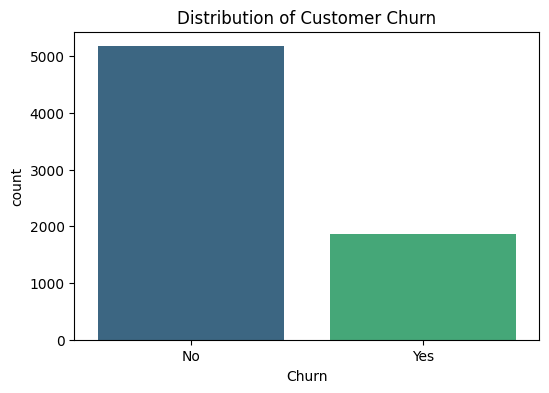

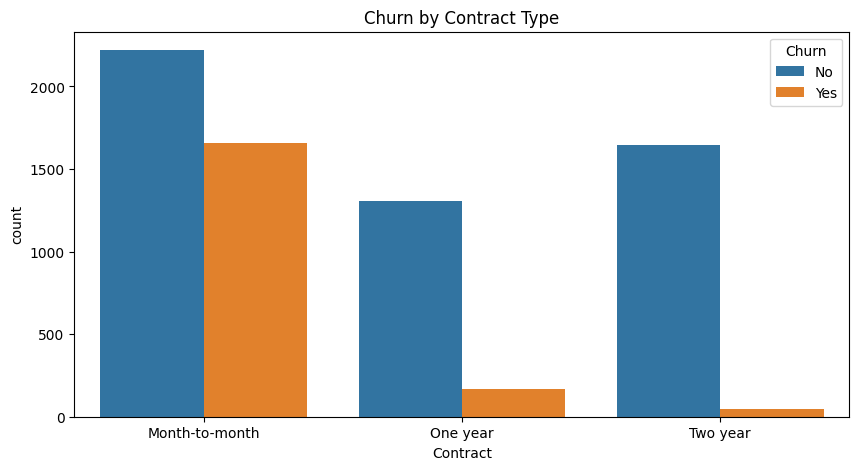

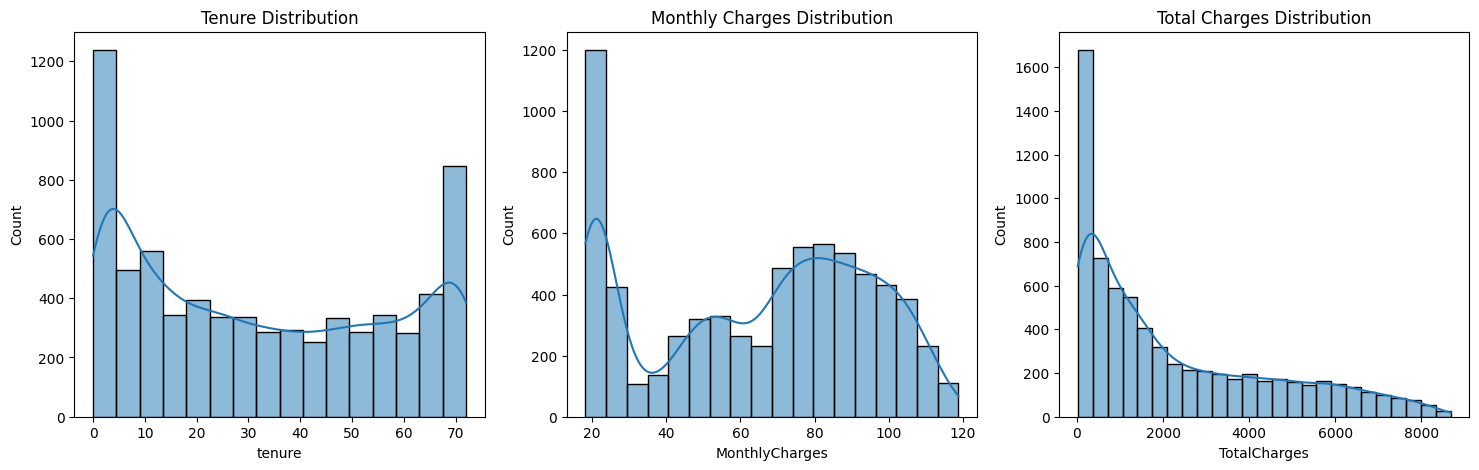

In [19]:
# Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.show()

# Churn by Contract Type (Crucial Business Insight)
plt.figure(figsize=(10,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

# Numerical Feature Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['tenure'], kde=True, ax=axes[0]).set_title('Tenure Distribution')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1]).set_title('Monthly Charges Distribution')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2]).set_title('Total Charges Distribution')
plt.show()

## 3. Model Training and Evaluation

In [20]:
# 1. Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# 2. Splitting
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Save the model locally for Streamlit
joblib.dump(model, 'telco_churn_model.pkl')

C:\Users\Ashish\AppData\Local\Temp\ipykernel_27068\4153289723.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Model Accuracy: 0.80

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



['telco_churn_model.pkl']

## 4. Categorical Data Encoding and Encoder Mapping

In [21]:
from sklearn.preprocessing import LabelEncoder

# List of columns that need encoding
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Fit on the data and transform it
    df[col] = le.fit_transform(df[col])
    # Store the fitted encoder in our dictionary
    encoders[col] = le

## 5. Saving Categorical Encoders for Deployment

In [22]:
import joblib
import os

# Create the folder if it's missing
if not os.path.exists('models'):
    os.makedirs('models')

# Save the dictionary as a .pkl file
joblib.dump(encoders, r'models/encoders.pkl')

print("Encoders saved successfully!")

Encoders saved successfully!


## 6. Final Export of Model Artifacts and Training Metadata

In [23]:
import joblib
import os

# 1. Create a 'models' folder if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Save the trained model
# Replace 'best_model' with the name of your model variable (e.g., rf_model, log_reg)
joblib.dump(model, r'models/churn_model.pkl')

# 3. Save the LabelEncoders/OneHotEncoders
# This assumes you stored them in a dictionary named 'encoders'
joblib.dump(encoders, r'models/encoders.pkl')

# 4. Save the exact list of feature names used for training
# This is crucial for matching column order later
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, r'models/feature_columns.pkl')

print("All artifacts saved successfully in the /models folder!")

All artifacts saved successfully in the /models folder!
